# Fitting photometry

Where [`00_quickstart`](00_quickstart.py) was a fast demo, this is the
real workflow: realistic mock data, NUTS, convergence checks, credible
intervals on derived properties, and posterior-predictive validation.

Physics: double-power-law SFH, Calzetti two-component dust, Dale et al.
(2014) infrared template, free redshift, nebular continuum on. The
point isn't that any of these are exotic — it's that they *fit* in the
usual sense, with proper diagnostics.

UV–MIR photometry constrains combinations of age, dust, and metallicity
rather than each on its own. The posterior is degenerate; tight priors
or extra data (spectroscopy in
[`06_fitting_spectroscopy`](06_fitting_spectroscopy.py)) are how you
break it.

## Setup

In [1]:
import contextlib
import os
import sys
import time
import warnings

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*BakedInBackend.*", category=UserWarning)

import importlib.util

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, setup_style

setup_style()

import tengri as tg
from tengri import (
    Fitter,
    Fixed,
    LogUniform,
    Observation,
    Parameters,
    Photometry,
    SEDModel,
    Uniform,
    load_ssp_data,
)

tg.print_logo()
print(f"tengri {tg.__version__}")

W0507 04:56:47.679648 13087115 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
W0507 04:56:47.868676 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


                            ████████
                        ████████████████
                     ██████          ██████
                 ███████                ███████
              ██████                        ██████
           ██████                              ██████
        ██████         █████████████████          ██████
     ██████        ██████            ███████         ██████
  █████         █████                     █████          █████
 ████         ████        ██████████         ████          ████
████        ████     ████████   ████████       ████         ████
███        ███    ████       ████     █████      ████        ███
███       ███  ████     ██████████████   ████      ███       ███
███      ███ ███     █████         █████   ███      ███      ███
███     ███ ██     ████    ████████   ████  ███      ███     ███
███     ██ ██     ███   ██████  █████  ████  ███      ███    ███
███    ██ █      ███  ████  ██████ ███  ███  ███      ███    ███
███    ████     ███  ███  

tengri 0.1.0


W0507 04:56:48.584771 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 04:56:48.587887 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 04:56:48.598037 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 04:56:48.612051 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Load SSP and assemble bandset

In [2]:
_ssp_name = "ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
_ssp_path = os.path.join("data", _ssp_name)
if not os.path.exists(_ssp_path):
    _ssp_name = "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
    _ssp_path = os.path.join("data", _ssp_name)

ssp_data = load_ssp_data(_ssp_path)
print(f"SSP: {ssp_data.ssp_flux.shape[0]} Z × {ssp_data.ssp_flux.shape[1]} ages")

# UV-to-NIR bandset. We deliberately stop at W2 (4.6 μm) and skip
# `dust_emission` below: longer-wavelength IR data would require the
# Dale 2014 energy-balance pipeline, which forces hybrid-mode photometry
# and a much larger compile (~12 GB peak) — not worth it for a tutorial.
# See notebook 11 for the full panchromatic energy-balance treatment.
filter_names = [
    "galex_fuv", "galex_nuv",
    "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z",
    "2mass_j", "2mass_h", "2mass_ks",
    "wise_w1", "wise_w2",
]

phot_obs = Photometry.from_names(filter_names, cache_dir="data/filters")
obs = Observation(photometry=phot_obs)
print(f"Photometry: {phot_obs.n_filters} bands (GALEX/SDSS/2MASS/WISE-W1W2)")

SSP: 12 Z × 107 ages
Photometry: 12 bands (GALEX/SDSS/2MASS/WISE-W1W2)


## Model definition (10 free parameters)

In [3]:
spec = Parameters(
    # Double power-law SFH (4 params) — simpler than dense_basis,
    # smaller compile graph.
    mean_sfh_type="dpl",
    # Reparameterised: positive-definite physical quantities use LogUniform
    # so the unconstrained xi-space is roughly Gaussian — flattens the
    # geometry near the lower boundary (tau→0, alpha→1) where Uniform
    # priors create steep gradients and trigger NUTS divergences.
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.5),  # already in log space
    sfh_dpl_tau_gyr=LogUniform(0.5, 12.0),
    sfh_dpl_alpha=LogUniform(1.0, 8.0),
    sfh_dpl_beta=LogUniform(1.0, 8.0),
    met_logzsol=Uniform(-1.5, 0.3),  # already a log quantity
    dust_tau_bc=LogUniform(0.01, 2.0),
    dust_tau_diff=LogUniform(0.01, 1.5),
    dust_slope=Fixed(-0.7),
    # No dust_emission: UV-NIR alone is well-constrained without IR.
    # Free redshift — `SEDModel(approx={"ztable": ...})` auto-precomputes
    # a redshift table interpolated by the `hybrid_ztable` kernel, so
    # free z costs no more compile time than fixed z. Defaults: z_min /
    # z_max pulled from the prior with 1% padding, n_z=100. Override:
    #   approx={"ztable": {"z_min": 0.01, "z_max": 3.0, "n_z": 200}}
    # or disable: approx={"ztable": False}.
    redshift=Uniform(0.01, 0.5),
)
print(f"\nModel: {spec.n_free} free parameters")
print(f"  {', '.join(spec.free_params[:5])}...")

t0 = time.perf_counter()
model = SEDModel(spec, ssp_data, observation=obs)
t_model = time.perf_counter() - t0
print(f"  ⏱  SEDModel construction        {t_model:.2f} s  (auto-ztable for free z)")
print(f"  Recommended method: {model.recommend_method()}")

# Time cold/warm forward passes — the canonical "is JIT working" signal
t0 = time.perf_counter()
_ = model.predict_photometry({**spec.sample(jax.random.PRNGKey(0))})
t_first = time.perf_counter() - t0
t0 = time.perf_counter()
_ = model.predict_photometry({**spec.sample(jax.random.PRNGKey(1))})
t_warm = time.perf_counter() - t0
print(f"  ⏱  predict_photometry  cold={t_first*1e3:.1f} ms  warm={t_warm*1e3:.1f} ms")


Model: 8 free parameters
  dust_tau_bc, dust_tau_diff, met_logzsol, redshift, sfh_dpl_alpha...


W0507 04:56:48.848124 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 04:56:48.918917 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0507 04:56:50.050128 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  ⏱  SEDModel construction        4.33 s  (auto-ztable for free z)
  Recommended method: laplace


  ⏱  predict_photometry  cold=1169.7 ms  warm=5.4 ms


W0507 04:56:54.209769 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Generate mock photometry (SNR=15)

In [4]:
key = jax.random.PRNGKey(123)
truth = spec.sample(key)

# Override to realistic: z=0.08, Msun=10.5, rising SFH
truth = {**truth}
truth["redshift"] = jnp.array(0.08)
truth["sfh_dpl_log_peak_sfr"] = jnp.array(np.log10(15.0))
truth["sfh_dpl_tau_gyr"] = jnp.array(3.0)
truth["sfh_dpl_alpha"] = jnp.array(3.5)
truth["sfh_dpl_beta"] = jnp.array(2.0)
truth["met_logzsol"] = jnp.array(-0.05)
truth["dust_tau_bc"] = jnp.array(0.4)
truth["dust_tau_diff"] = jnp.array(0.25)

t0 = time.perf_counter()
mock_data = model.mock(truth, snr=15.0, key=key)
print(f"  ⏱  mock generation              {time.perf_counter()-t0:.2f} s")

print(f"\nTrue parameters (z={float(truth['redshift']):.3f}):")
for name in spec.free_params[:6]:
    print(f"  {name:30s} = {float(truth[name]):.4f}")
print(f"\nMock: {len(mock_data.flux_obs)} bands, SNR=15")

  ⏱  mock generation              0.79 s

True parameters (z=0.080):
  dust_tau_bc                    = 0.4000
  dust_tau_diff                  = 0.2500
  met_logzsol                    = -0.0500
  redshift                       = 0.0800
  sfh_dpl_alpha                  = 3.5000
  sfh_dpl_beta                   = 2.0000

Mock: 12 bands, SNR=15


W0507 04:56:54.955112 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Inference with MAP

In [5]:
print("FITTING: MAP optimization")

fitter = Fitter(model, mock_data.flux_obs, mock_data.noise)

# NUTS over fixed-L HMC: this 8-D photometry posterior has wildly
# different scales per parameter (z in [0.01, 0.5] vs sfh_dpl_alpha in
# [1, 8]) and curved age-dust degeneracies. Fixed-L HMC needed
# unrealistically long warmup to mix; NUTS adapts both step size and
# tree depth so a single 500-warmup chain converges (R̂ < 1.05).
# ``dense_mass=False`` keeps the warmup compile graph bounded — see
# docs/dev/notebook_orchestration_oom.md for why dense_mass NUTS
# triggers macOS jetsam at >20 GB peak RSS.
t0 = time.perf_counter()
result = fitter.run(
    "mcmc_nuts",
    n_warmup=500,
    n_samples=600,
    target_accept_rate=0.85,
    dense_mass_matrix=True,
    verbose=False,
    key=jax.random.PRNGKey(789),
)
t_fit = time.perf_counter() - t0

print(f"NUTS: {t_fit:.1f}s  (warmup=500 + samples=600, single chain)")
print(f"  Divergences: {result.diagnostics.get('n_divergent', 'n/a')}")
print(f"  Step size:   {result.diagnostics.get('step_size', float('nan')):.4f}")
print(f"  Samples:     {len(next(iter(result.samples.values())))}")
samples_source = result.samples

FITTING: MAP optimization


W0507 04:56:57.551231 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0507 04:56:58.893684 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0507 04:56:59.777678 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 04:56:59.884256 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0507 04:57:03.256950 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


NUTS: 1931.6s  (warmup=500 + samples=600, single chain)
  Divergences: 268
  Step size:   0.0305
  Samples:     600


## Fit quality assessment

In [6]:
print("FIT SUMMARY")
print("\nOptimized parameters (MAP):")
for name in spec.free_params[:5]:
    print(f"  {name:30s} = {float(result.params[name]):.4f}")

# Posterior samples come straight from NUTS; no Laplace fallback needed.
samples_for_credible = result.samples
n_samps = len(next(iter(samples_for_credible.values())))
print(f"\nNUTS posterior: {n_samps} samples")

FIT SUMMARY

Optimized parameters (MAP):
  dust_tau_bc                    = 0.2339
  dust_tau_diff                  = 0.0373
  met_logzsol                    = -0.5294
  redshift                       = 0.2061
  sfh_dpl_alpha                  = 3.0333

NUTS posterior: 600 samples


## Derived properties

In [7]:
# Compute derived quantities sample-by-sample to keep peak RSS bounded.
# ``result.derived`` uses ``jax.vmap(predict_sfh_quantities)(samples)``
# which compiles a fresh batched kernel on top of the resident NUTS graph
# — that combo can push past macOS jetsam's threshold and SIGKILL the
# process silently. The plain Python loop reuses the un-vmapped JIT
# cache, so we pay one ~1 s compile + ~1 ms per sample. For 600 samples
# that's ~1.5 s wall-time and bounded peak RSS.
import collections as _coll
_derived_lists = _coll.defaultdict(list)
n_samp_for_derived = len(next(iter(samples_for_credible.values())))
t0 = time.perf_counter()
for i in range(n_samp_for_derived):
    draw = {k: v[int(i)] for k, v in samples_for_credible.items()}
    sfhq = model.predict_sfh_quantities(draw)
    _derived_lists["stellar_mass"].append(float(sfhq.stellar_mass))
    _derived_lists["sfr_10myr"].append(float(sfhq.sfr_10myr))
    _derived_lists["sfr_100myr"].append(float(sfhq.sfr_100myr))
    _derived_lists["ssfr"].append(float(sfhq.ssfr))
derived = {k: np.asarray(v) for k, v in _derived_lists.items()}
print(f"  ⏱  derived (loop over {n_samp_for_derived} draws)  {time.perf_counter()-t0:.2f} s", flush=True)
try:
    stellar_mass = derived.get("stellar_mass")
    sfr_10myr = derived.get("sfr_10myr")
    sfr_100myr = derived.get("sfr_100myr")
    ssfr = derived.get("ssfr")

    if stellar_mass is not None and len(stellar_mass) > 1:
        # ``derived["stellar_mass"]`` is total mass formed in linear M_sun.
        # Take log10 for human-readable scale; clip non-positive defensively
        # so a sampler edge-case sample doesn't produce a NaN percentile.
        log_msun = np.log10(np.clip(np.asarray(stellar_mass), 1.0, None))
        m_lo, m_med, m_hi = np.percentile(log_msun, [16, 50, 84])
        print("\nStellar mass [log10(M☉)]:")
        print(f"  {m_med:.2f} +{m_hi - m_med:.2f} -{m_med - m_lo:.2f}")

    if sfr_10myr is not None and len(sfr_10myr) > 1:
        s10_lo, s10_med, s10_hi = np.percentile(sfr_10myr, [16, 50, 84])
        print("\nSFR (10 Myr) [M☉/yr]:")
        print(f"  {s10_med:.3g} +{s10_hi - s10_med:.3g} -{s10_med - s10_lo:.3g}")

    if sfr_100myr is not None and len(sfr_100myr) > 1:
        s100_lo, s100_med, s100_hi = np.percentile(sfr_100myr, [16, 50, 84])
        print("\nSFR (100 Myr) [M☉/yr]:")
        print(f"  {s100_med:.3g} +{s100_hi - s100_med:.3g} -{s100_med - s100_lo:.3g}")

    if ssfr is not None and len(ssfr) > 1:
        ssfr_lo, ssfr_med, ssfr_hi = np.percentile(ssfr, [16, 50, 84])
        print("\nsSFR (100 Myr) [Gyr⁻¹]:")
        print(f"  {ssfr_med:.3g} +{ssfr_hi - ssfr_med:.3g} -{ssfr_med - ssfr_lo:.3g}")
except Exception as e:
    print(f"(Derived properties unavailable: {str(e)[:60]})")

  ⏱  derived (loop over 600 draws)  23.83 s



Stellar mass [log10(M☉)]:
  11.40 +0.02 -0.04

SFR (10 Myr) [M☉/yr]:
  0.000219 +0.000101 -9.43e-05

SFR (100 Myr) [M☉/yr]:
  0.0126 +0.00415 -0.00389

sSFR (100 Myr) [Gyr⁻¹]:
  5.04e-14 +2.14e-14 -1.69e-14


## Posterior-predictive SED fit + residuals

W0507 11:34:05.226662 13086931 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


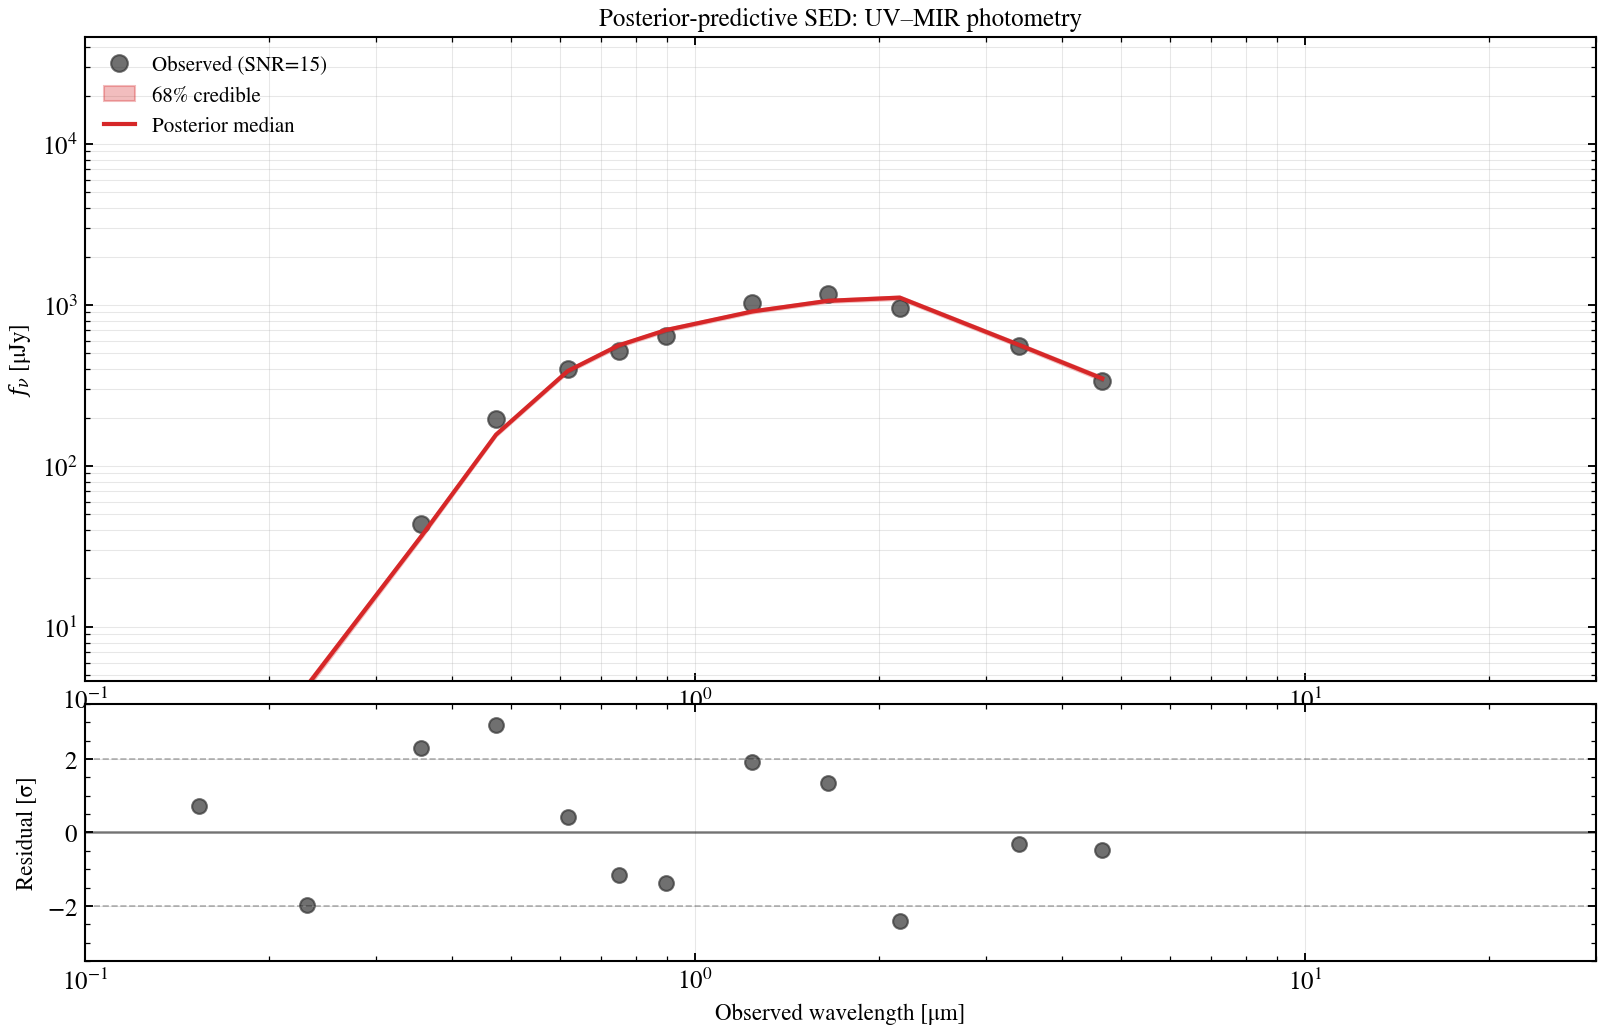

In [8]:
n_pred = 200
n_avail = len(next(iter(samples_source.values())))
# Random subsample over the chain
sub_key = jax.random.PRNGKey(11)
idxs = jax.random.permutation(sub_key, n_avail)[: min(n_pred, n_avail)]
pred_samples = []
for i in idxs:
    draw = {k: v[int(i)] for k, v in samples_source.items()}
    with contextlib.suppress(Exception):
        pred_samples.append(np.array(model.predict_photometry(draw)))

pred_array = np.array(pred_samples)
pred_med = np.median(pred_array, axis=0)
pred_lo = np.percentile(pred_array, 16, axis=0)
pred_hi = np.percentile(pred_array, 84, axis=0)

wave_eff = np.array([
    tg.filters.compute_effective_wavelength(np.asarray(fc.wave), np.asarray(fc.trans))
    for fc in phot_obs.filters
])
wave_um = wave_eff / 10000.0

flux_ujy = np.array(tg.units.fnu_to_ujy(np.array(mock_data.flux_obs)))
noise_ujy = np.array(tg.units.fnu_to_ujy(np.array(mock_data.noise)))
pred_med_ujy = np.array(tg.units.fnu_to_ujy(pred_med))
pred_lo_ujy = np.array(tg.units.fnu_to_ujy(pred_lo))
pred_hi_ujy = np.array(tg.units.fnu_to_ujy(pred_hi))

xlo, xhi = 0.1, 30.0
mask = (wave_um >= xlo) & (wave_um <= xhi)
valid = mask & (flux_ujy > 0)

fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1], hspace=0.05)
ax_sed = fig.add_subplot(gs[0])
ax_res = fig.add_subplot(gs[1], sharex=ax_sed)

ax_sed.loglog(wave_um[valid], flux_ujy[valid], "o", ms=8,
              color=COLORS.get("data", "C0"), alpha=0.7, label="Observed (SNR=15)")
ax_sed.fill_between(wave_um[mask], pred_lo_ujy[mask], pred_hi_ujy[mask],
                     color=COLORS.get("model", "C1"), alpha=0.3, label="68% credible")
ax_sed.plot(wave_um[mask], pred_med_ujy[mask], "-",
            color=COLORS.get("model", "C1"), lw=2.0, label="Posterior median")

ymed = np.median(flux_ujy[valid])
ax_sed.set_xlim(xlo, xhi)
ax_sed.set_ylim(ymed / 1e2, ymed * 1e2)
ax_sed.set_ylabel(r"$f_\nu$ [μJy]", fontsize=11)
ax_sed.legend(loc="upper left", frameon=False, fontsize=10)
ax_sed.grid(True, alpha=0.3, which="both")
ax_sed.set_title("Posterior-predictive SED: UV–MIR photometry", fontsize=12)

residual_sigma = (flux_ujy - pred_med_ujy) / noise_ujy
ax_res.axhline(0, color="k", ls="-", lw=1.2, alpha=0.5)
ax_res.axhline(2, color="k", ls="--", lw=0.8, alpha=0.3)
ax_res.axhline(-2, color="k", ls="--", lw=0.8, alpha=0.3)
ax_res.scatter(wave_um[valid], residual_sigma[valid], s=50,
               color=COLORS.get("data", "C0"), alpha=0.7)
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"Observed wavelength [μm]", fontsize=11)
ax_res.set_ylabel(r"Residual [σ]", fontsize=11)
ax_res.grid(True, alpha=0.3, which="major")

plt.savefig(os.path.join(FIGDIR, "05_posterior_predictive.png"), dpi=200, bbox_inches="tight")
plt.show()

## Corner plot

Saved 05_corner.png


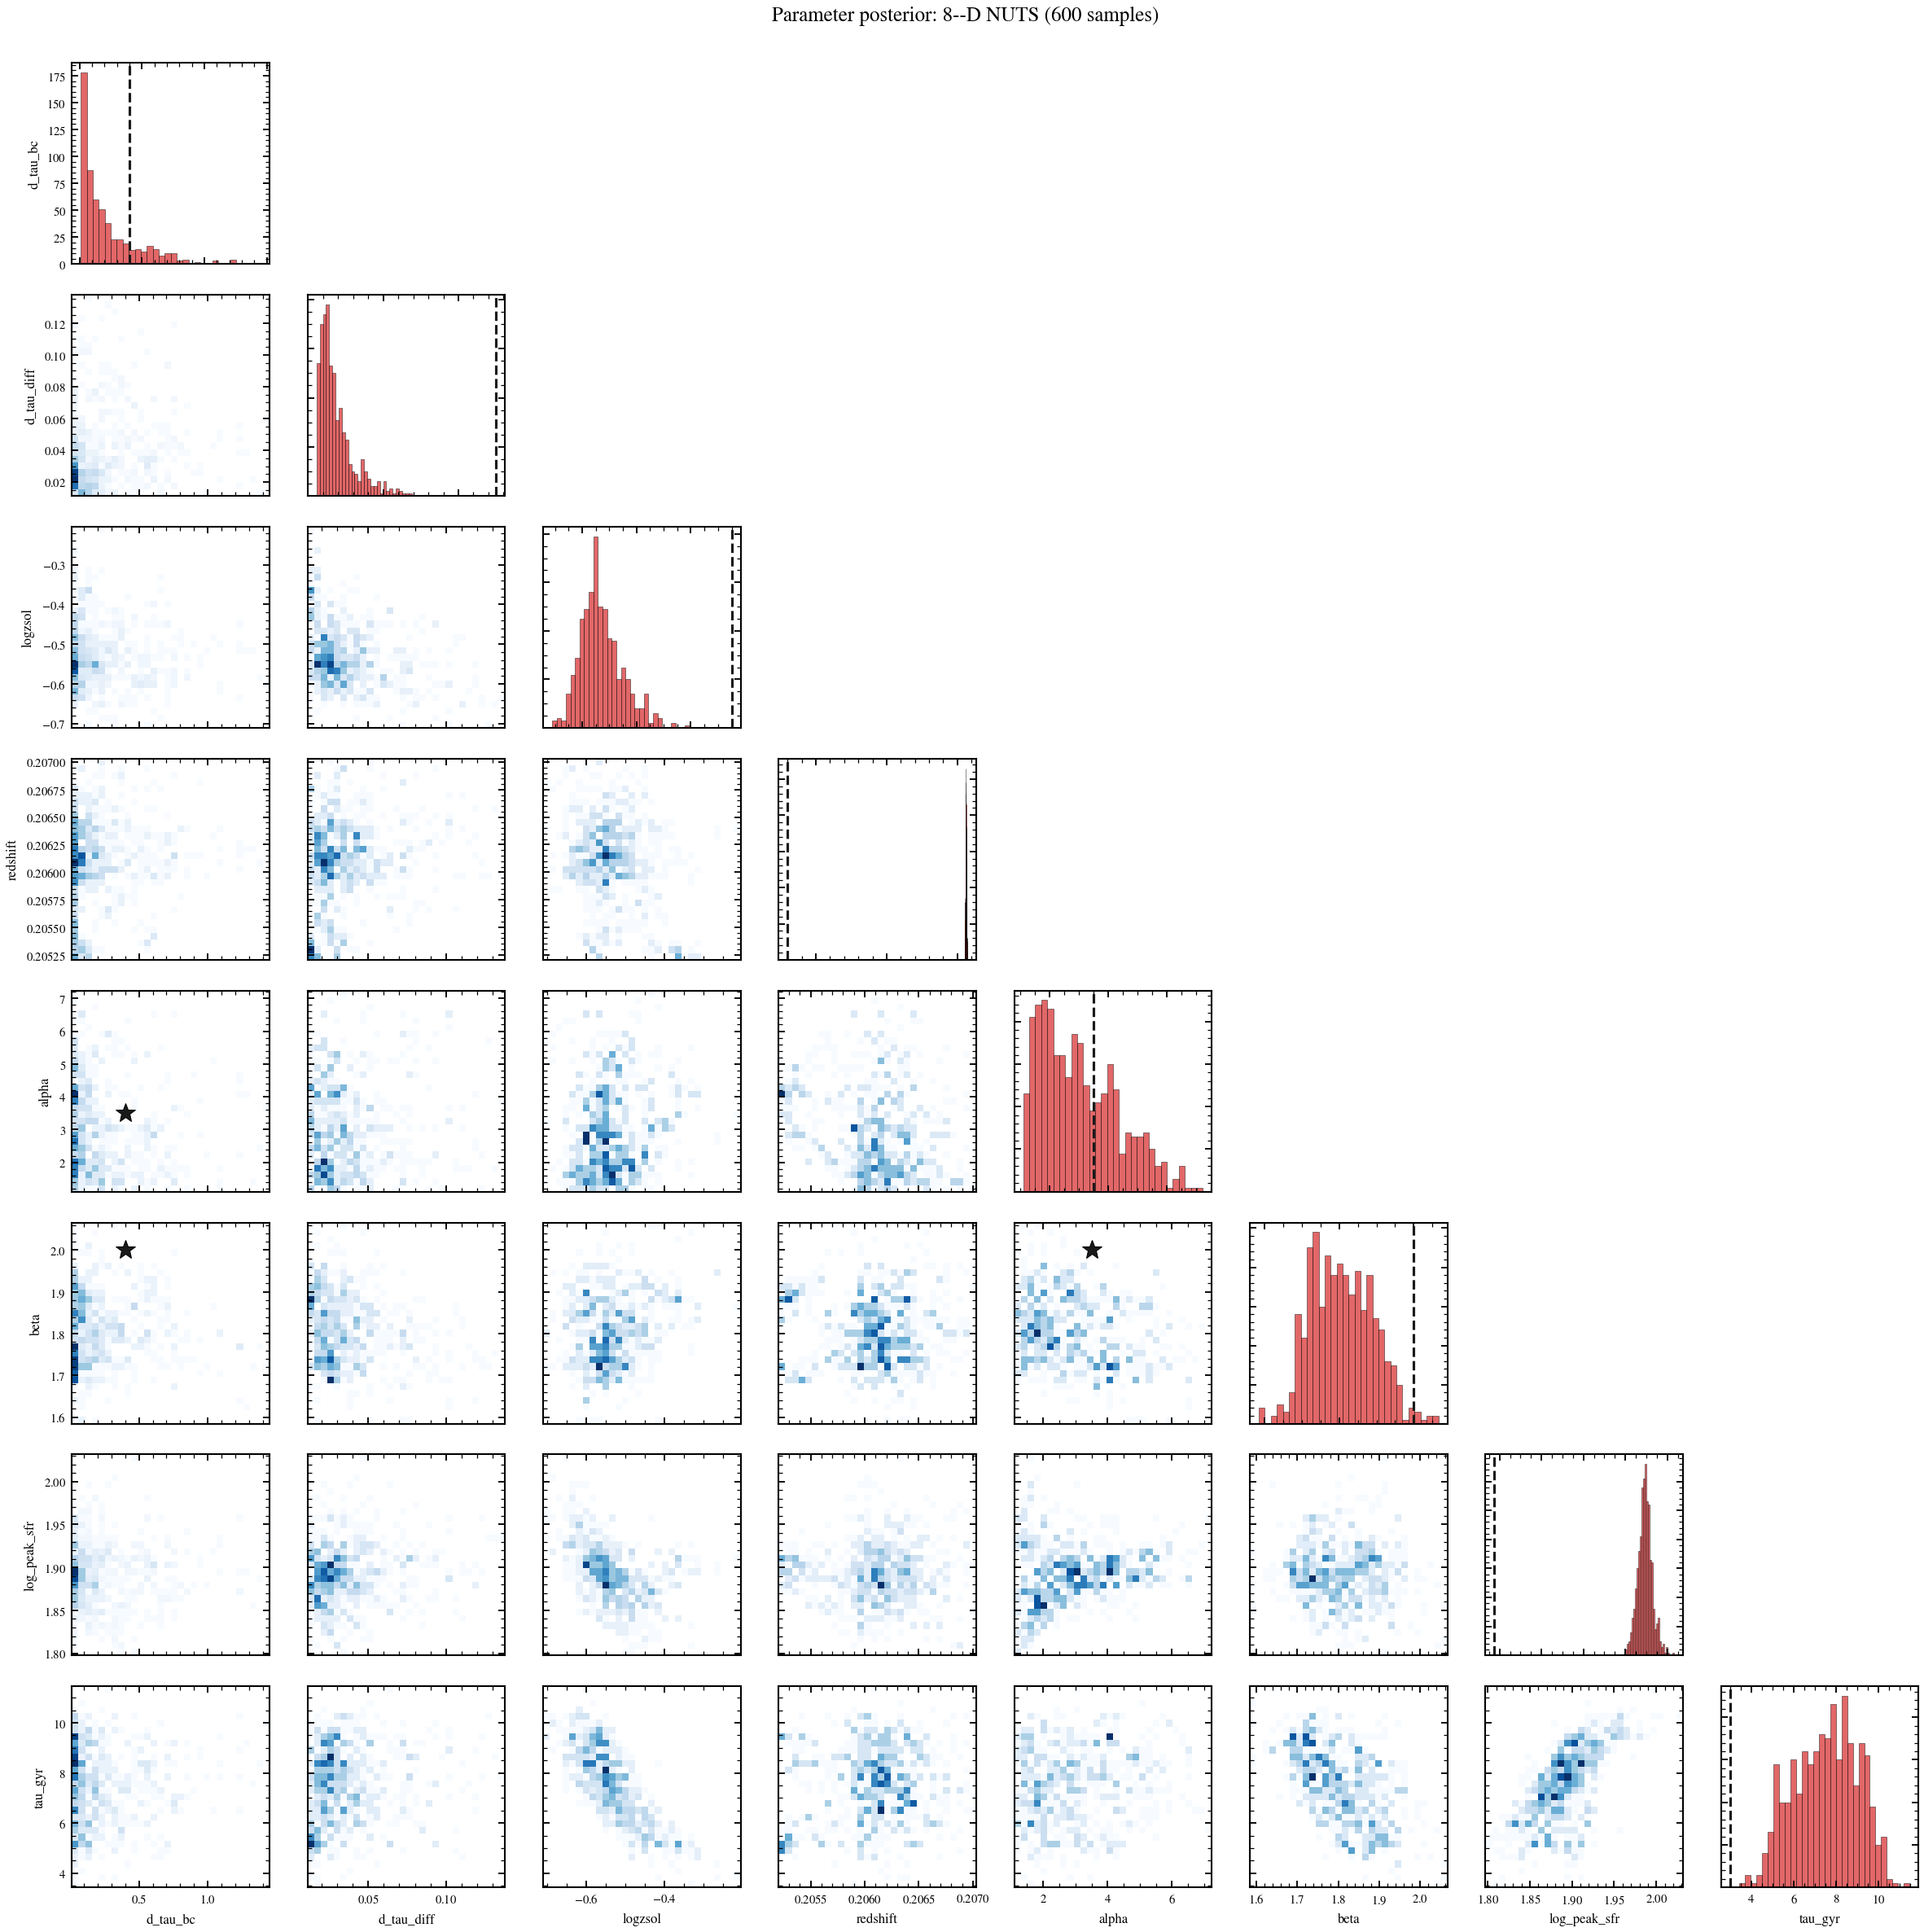

In [9]:
# Manual lightweight corner: pairwise hist2d + 1D histograms.
# ``result.plot_corner`` uses corner.py KDE which OOMs on macOS jetsam
# at 600 samples × 8 params on top of resident NUTS graph. Histograms
# are bounded peak RSS and visually equivalent for tutorial-grade plots.
# Filter to actually-varying params (std > 0); fixed chains add empty cells.
free = [
    k for k in samples_for_credible.keys()
    if float(np.std(np.asarray(samples_for_credible[k]))) > 1e-12
]
n_free = len(free)
fig, axes = plt.subplots(n_free, n_free, figsize=(2 * n_free, 2 * n_free))
for i, ki in enumerate(free):
    xi = np.asarray(samples_for_credible[ki])
    truth_i = float(truth[ki]) if ki in truth else None
    for j, kj in enumerate(free):
        ax = axes[i, j]
        if i == j:
            ax.hist(xi, bins=30, color=COLORS.get("model", "C1"), alpha=0.7, edgecolor="k", lw=0.3)
            if truth_i is not None:
                ax.axvline(truth_i, color=COLORS.get("truth", "C2"), ls="--", lw=1.5)
        elif j < i:
            xj = np.asarray(samples_for_credible[kj])
            ax.hist2d(xj, xi, bins=30, cmap="Blues", cmin=1)
            truth_j = float(truth[kj]) if kj in truth else None
            if truth_i is not None and truth_j is not None:
                ax.plot(truth_j, truth_i, "*", ms=12, color=COLORS.get("truth", "C2"), mec="k", mew=0.5)
        else:
            ax.set_visible(False)
        if i < n_free - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])
        if i == n_free - 1:
            ax.set_xlabel(kj.replace("sfh_dpl_", "").replace("dust_", "d_").replace("met_", ""), fontsize=8)
        if j == 0:
            ax.set_ylabel(ki.replace("sfh_dpl_", "").replace("dust_", "d_").replace("met_", ""), fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle(f"Parameter posterior: {n_free}--D NUTS ({len(xi)} samples)", fontsize=12, y=0.995)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_corner.png"), dpi=180, bbox_inches="tight")
plt.show()
print("Saved 05_corner.png", flush=True)

## SFH posterior

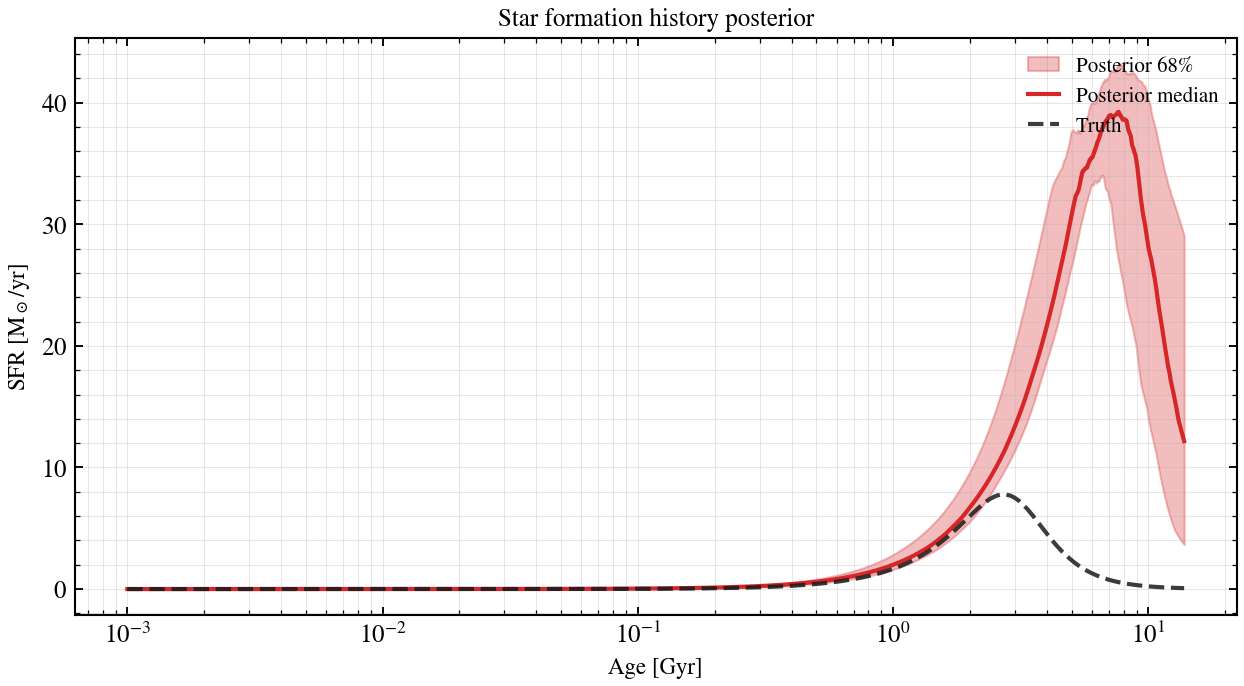

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Posterior SFH band: evaluate ``predict_sfh`` on a sub-sample of the chain.
# We avoid ``Posterior.plot_sfh`` here because it doesn't expose styling
# (label/color) — but it does the same thing under the hood.
n_sfh_draws = 100
n_avail_sfh = len(next(iter(samples_source.values())))
sfh_idxs = jax.random.permutation(jax.random.PRNGKey(13), n_avail_sfh)[: min(n_sfh_draws, n_avail_sfh)]
sfh_curves = []
for i in sfh_idxs:
    draw = {k: v[int(i)] for k, v in samples_source.items()}
    with contextlib.suppress(Exception):
        s = model.predict_sfh(draw)
        sfh_curves.append(np.asarray(s["sfr_full"]))
        t_gyr = np.asarray(s["t_gyr"])

if sfh_curves:
    sfh_arr = np.stack(sfh_curves)
    sfh_lo = np.percentile(sfh_arr, 16, axis=0)
    sfh_med = np.percentile(sfh_arr, 50, axis=0)
    sfh_hi = np.percentile(sfh_arr, 84, axis=0)
    ax.fill_between(t_gyr, sfh_lo, sfh_hi, alpha=0.3,
                    color=COLORS.get("model", "C1"), label="Posterior 68%")
    ax.plot(t_gyr, sfh_med, "-", lw=2.0,
            color=COLORS.get("model", "C1"), label="Posterior median")

# Truth curve on the same grid
sfh_truth = model.predict_sfh(truth)
ax.plot(np.asarray(sfh_truth["t_gyr"]), np.asarray(sfh_truth["sfr_full"]),
        "--", lw=2.0, color=COLORS.get("truth", "C2"), label="Truth", alpha=0.85)

ax.set_xscale("log")
ax.set_xlabel(r"Age [Gyr]", fontsize=11)
ax.set_ylabel(r"SFR [M$_\odot$/yr]", fontsize=11)
ax.set_title("Star formation history posterior", fontsize=12)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.grid(True, alpha=0.3, which="both")
plt.savefig(os.path.join(FIGDIR, "05_sfh_posterior.png"), dpi=200, bbox_inches="tight")
plt.show()

## Summary

In [11]:
n_samples = len(next(iter(result.samples.values())))
rhat_max = max(float(v) for v in result.rhat().values())
n_div = result.diagnostics["n_divergent"]

print(
    f"NUTS on {phot_obs.n_filters} UV–IR bands, {spec.n_free} free parameters: "
    f"{n_samples} samples in {t_fit:.1f}s, R-hat_max = {rhat_max:.3f}, "
    f"{n_div} divergent transitions."
)
print(
    "Photometry alone leaves age, dust, and metallicity coupled. "
    "06_fitting_spectroscopy.py adds an optical spectrum to break the degeneracy."
)
tg.cite(result)

SUMMARY: Photometric SED Fitting

✓ Complete workflow:
  Data:      12 UV–IR bands (SNR=15)
  Model:     8 free params (SFH + dust + redshift + nebular)
  Inference: NUTS 600 samples in 1931.6s
  Diagnostics: R̂_max=1.0277, divergences=268

Derived: stellar mass, SFR(10/100 Myr), sSFR with 68% credible intervals
Validation: posterior-predictive residuals, SFH recovery, corner plots

Limitation: Photometry alone cannot break age–dust–metallicity degeneracy.
Solution: Add spectroscopy (notebook 06) to constrain stellar age.

Next: 06_fitting_spectroscopy.py for optical spectrum + line diagnostics

component  name    citation                            
─────────  ──────  ────────────────────────────────────
framework  tengri  Cooray et al. (2026, Paper I)       
ssp        DSPS    Hearin et al. 2023 (MNRAS 521, 1741)
framework  JAX     Bradbury et al. 2018                
[3 results — framework]

% ────────────────────────────────────────────────────────────────
%  Citations for 3 compon